In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-06-17T14:28:29.164391+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

requests  : 2.34.2
matplotlib: 3.10.7
seaborn   : 0.13.2
teeplot   : 1.4.2
numpy     : 2.1.2
pandas    : 2.2.3
marimo    : 0.23.2

```

## Data

Load the per-replicate **strain** and **Hamming-weight** prevalence
time series produced by the 3-site mutation-rate sweep slurm job
(`slurm/2026-06-17/2026-06-17-3site-mutation-sweep.sh`, driven by
notebook `bindle/2026-05-20-founder.py`), cached as parquets on OSF.
The sweep fixes `N_SITES=3` and steps `MUTATION_RATE` across a
geometric grid of 17 conditions spanning `1e-9` to `1e-1` (~2 points
per decade), with a handful of replicates retained per rate at 5000
steps each, POP_SIZE=1_000_000, on CPU (engine=numpy).

Two long-form frames back this notebook, keyed by the shared
`replicate_uid` and `Step`:

- **strain** (`f4bzv`): one row per `(replicate_uid, Step, strain)`
  genome (`strain` in `0 .. 2**N_SITES - 1`), with per-genome
  prevalence `count` (population fraction) and raw case count
  `n_cases`. A strain's Hamming weight is its genome bit-count ---
  the number of mutations separating it from the all-zero founder.
- **hw** (`4mrgu`): one row per `(replicate_uid, Step, hw)`
  Hamming-weight band (`hw` in `0 .. N_SITES`), aggregating the
  per-genome counts into the per-weight prevalence `count`. Each
  band equals the sum of its same-weight strains.

Both slugs are downloaded with `requests` and cached at `/tmp/<slug>`
so re-runs hit the local copy.

This is the **early-window variant** of
`bindle/2026-06-17-3site-strain-trajectories.py`: it **excludes the
slowest `1e-9` mutation rate** and **clips each trajectory to the
first `2000` updates** to zoom in on the establishment-phase
dynamics.

In [ ]:
# CLI args. Defaults pull the 3-site mutation-sweep strain + hw
# trajectory parquets that back this notebook. STEP_CLIP bounds the
# plotted window to the first N updates.
_args = mo.cli_args()
OSF_SLUG_STRAIN = str(_args.get("osf-slug-strain") or "f4bzv")
OSF_SLUG_HW = str(_args.get("osf-slug-hw") or "4mrgu")
STEP_CLIP = int(_args.get("step-clip") or 2000)
print(
    f"args: OSF_SLUG_STRAIN={OSF_SLUG_STRAIN} "
    f"OSF_SLUG_HW={OSF_SLUG_HW} STEP_CLIP={STEP_CLIP}",
)

args: OSF_SLUG_STRAIN=f4bzv OSF_SLUG_HW=4mrgu STEP_CLIP=2000


In [ ]:
def _fetch(slug):
    cache_path = pathlib.Path("/tmp") / slug
    url = f"https://osf.io/{slug}/download"
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=240)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return pd.read_parquet(cache_path)

strain_df = _fetch(OSF_SLUG_STRAIN)
hw_df = _fetch(OSF_SLUG_HW)
print(f"loaded strain dataframe: {strain_df.shape}")
print(f"loaded hw dataframe: {hw_df.shape}")
print(
    "mutation_rate x replicate counts (hw):\n"
    + str(hw_df.groupby("mutation_rate")["replicate_uid"].nunique()),
)

downloading https://osf.io/f4bzv/download -> /tmp/f4bzv
size: 32413059 bytes
downloading https://osf.io/4mrgu/download -> /tmp/4mrgu
size: 8169481 bytes
loaded strain dataframe: (2680000, 23)
loaded hw dataframe: (1340000, 20)
mutation_rate x replicate counts (hw):
mutation_rate
1.000000e-09    4
3.000000e-09    4
1.000000e-08    4
3.000000e-08    4
1.000000e-07    4
               ..
1.000000e-03    4
3.000000e-03    4
1.000000e-02    4
3.000000e-02    4
1.000000e-01    4
Name: replicate_uid, Length: 17, dtype: int64


## Trellis Layout & Hamming-Weight Coloring

Tag every strain genome with its **Hamming weight** (`bit-count`) so
the per-genome curves can be colored by weight, matching the
aggregated `hw` bands. Both frames are then **clipped to the first
`STEP_CLIP` (2000) updates** so the trellis zooms in on the
establishment-phase dynamics rather than the long endemic tail.

Build the trellis index from the clipped frames: keep only the
**power-of-ten mutation rates** and additionally **drop the slowest
`1e-9`** condition, leaving `1e-8 .. 1e-1`. Lay these out with **one
column per `mutation_rate`** increasing **left to right** and **one
row per within-rate replicate** (ordered by `replicate_uid`), so each
panel is a single replicate's clipped trajectory and reading across a
row walks the mutation-rate sweep.

The per-step series are subsampled by `STRIDE` for plotting (the
curves are smooth, so thinning to ~1000 points per line keeps the
figure light without changing its shape).

In [ ]:
N_SITES = int(hw_df["n_sites"].iloc[0])

# Clip both frames to the first STEP_CLIP updates.
hw_clip_df = hw_df[hw_df["Step"] < STEP_CLIP]
strain_clip_df = strain_df[strain_df["Step"] < STEP_CLIP]

STRIDE = max(1, int(strain_clip_df["Step"].nunique()) // 1000)

# Hamming weight of each genome == popcount of the strain index.
strain_hw_df = strain_clip_df.assign(
    hw=strain_clip_df["strain"].map(lambda _s: bin(int(_s)).count("1")),
)

# Restrict to the power-of-ten mutation rates and drop the slowest
# 1e-9 condition, leaving 1e-8 .. 1e-1. Trellis columns are these
# rates increasing left to right; rows are within-rate replicates
# (ordered by replicate_uid for determinism).
rate_vals = [
    _r
    for _r in sorted(hw_clip_df["mutation_rate"].unique().tolist())
    if f"{_r:.0e}".startswith("1e") and f"{_r:.0e}" != "1e-09"
]
reps_by_rate = {
    _rate: sorted(
        hw_clip_df[hw_clip_df["mutation_rate"] == _rate][
            "replicate_uid"
        ].unique(),
    )
    for _rate in rate_vals
}
max_reps = max(len(_r) for _r in reps_by_rate.values())
print(f"N_SITES={N_SITES} STRIDE={STRIDE} STEP_CLIP={STEP_CLIP}")
print(
    f"grid: {max_reps} replicates (rows) x {len(rate_vals)} rates (cols)"
)

N_SITES=3 STRIDE=2 STEP_CLIP=2000
grid: 4 replicates (rows) x 8 rates (cols)


## Replicate Trajectory Trellis (First 2000 Updates)

One panel per replicate, trellised by `mutation_rate` (columns,
increasing left to right) over within-rate replicates (rows), with
each trajectory **clipped to the first 2000 updates**. In each panel:

- **solid** lines are individual **strain** (per-genome) prevalence
  trajectories, **color-coded by Hamming weight**;
- **dashed** lines are the aggregated **Hamming-weight band**
  prevalences in the same color scheme.

Hamming weights use a categorical palette in which the **extreme
weights `0` and `3`** (the founder `000` and its complement `111`)
are **cool** (blue / cyan) and the **intermediate weights `1` and
`2`** are **warm** (orange / red), so the founder-aligned and
intermediate classes read apart at a glance.

These are individual replicate trajectories, so **no confidence
interval** is drawn --- every line is one realized run. The dashed
band of a given color is the sum of the solid strain curves sharing
that Hamming weight.

teeplots/2026-06-17-3site-strain-trajectories-clip2000/a=strain-vs-hw-replicate-trellis-clip2000+viz=subplots+ext=.pdf
teeplots/2026-06-17-3site-strain-trajectories-clip2000/a=strain-vs-hw-replicate-trellis-clip2000+viz=subplots+ext=.png


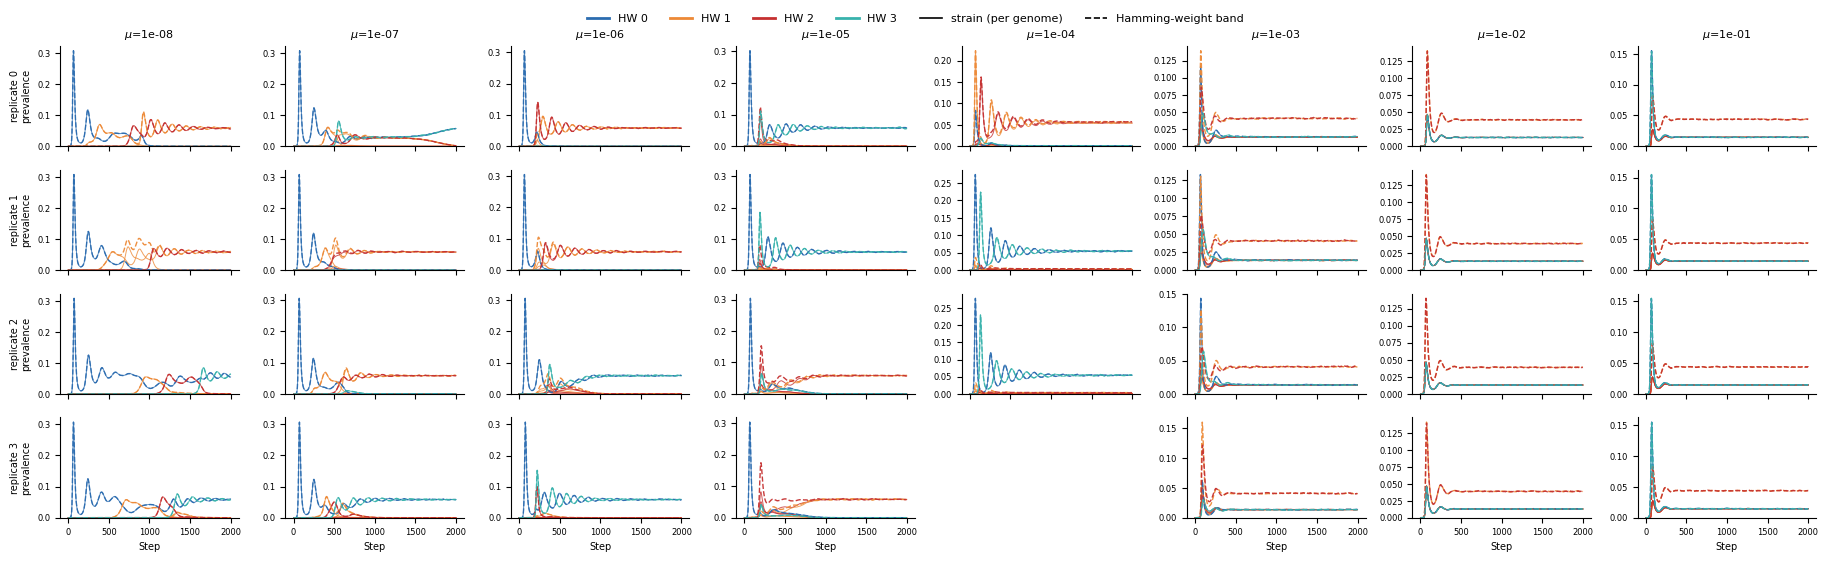

In [ ]:
# Categorical Hamming-weight palette: extreme weights 0 & 3 (founder
# 000 and complement 111) cool, intermediate weights 1 & 2 warm.
_hw_colors = ["#2b6cb0", "#ed8936", "#c53030", "#38b2ac"]
_n_cols = len(rate_vals)
_n_rows = int(max_reps)

with tp.teed(
    plt.subplots,
    nrows=_n_rows,
    ncols=_n_cols,
    figsize=(2.3 * _n_cols, 1.4 * _n_rows),
    sharex=True,
    squeeze=False,
    teeplot_outattrs={"a": "strain-vs-hw-replicate-trellis-clip2000"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (_fig, _axes):
    for _i, _rate in enumerate(rate_vals):
        _reps = reps_by_rate[_rate]
        for _j in range(_n_rows):
            _ax = _axes[_j][_i]
            if _j >= len(_reps):
                _ax.axis("off")
                continue
            _rid = _reps[_j]
            _h = hw_clip_df[
                hw_clip_df["replicate_uid"] == _rid
            ].sort_values("Step")
            _s = strain_hw_df[
                strain_hw_df["replicate_uid"] == _rid
            ].sort_values("Step")

            # Solid: per-genome strain prevalence, colored by hw.
            for _strain in sorted(_s["strain"].unique()):
                _ss = _s[_s["strain"] == _strain].iloc[::STRIDE]
                _w = bin(int(_strain)).count("1")
                _ax.plot(
                    _ss["Step"],
                    _ss["count"],
                    linestyle="-",
                    linewidth=0.7,
                    color=_hw_colors[_w],
                    alpha=0.8,
                )
            # Dashed: aggregated Hamming-weight band prevalence.
            for _w in range(N_SITES + 1):
                _hh = _h[_h["hw"] == _w].iloc[::STRIDE]
                _ax.plot(
                    _hh["Step"],
                    _hh["count"],
                    linestyle="--",
                    linewidth=1.0,
                    color=_hw_colors[_w],
                    alpha=0.95,
                )

            _ax.set_ylim(bottom=0)
            _ax.tick_params(labelsize=6)
            if _i == 0:
                _ax.set_ylabel(
                    f"replicate {_j}\nprevalence",
                    fontsize=7,
                )
            if _j == 0:
                _ax.set_title(f"$\\mu$={_rate:.0e}", fontsize=8)
            if _j == _n_rows - 1:
                _ax.set_xlabel("Step", fontsize=7)
            sns.despine(ax=_ax)

    # Shared legend: Hamming-weight colors + line-style meaning.
    _handles = [
        mlines.Line2D(
            [],
            [],
            color=_hw_colors[_w],
            linewidth=2.0,
            label=f"HW {_w}",
        )
        for _w in range(N_SITES + 1)
    ]
    _handles += [
        mlines.Line2D(
            [],
            [],
            color="black",
            linestyle="-",
            linewidth=1.2,
            label="strain (per genome)",
        ),
        mlines.Line2D(
            [],
            [],
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="Hamming-weight band",
        ),
    ]
    _fig.legend(
        handles=_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.005),
        ncol=len(_handles),
        frameon=False,
        fontsize=8,
    )
    _fig.tight_layout(rect=(0, 0, 1, 0.99))